In [1]:
import qiskit
from qiskit import QuantumCircuit
import qiskit.quantum_info as qi
from qiskit.compiler import transpile
from qiskit.circuit.library import StatePreparation
from qiskit.primitives import StatevectorSampler
from qiskit import QuantumRegister, AncillaRegister
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import json
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import functools as ft
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter
import Hamiltonian as hm

SparsePauliOp(['IIXX', 'IIYY', 'IIZZ', 'IXXI', 'IYYI', 'IZZI', 'XXII', 'YYII', 'ZZII'],
              coeffs=[-1. +0.j, -1. +0.j, -1.1+0.j, -1. +0.j, -1. +0.j, -1.1+0.j, -1. +0.j,
 -1. +0.j, -1.1+0.j])


Okay, we're aiming for a CNOT depth of around 50. CNOT depth is how many CNOT gates occur one after the other. single qubit gates are fast, but two-qubit gates (like CNOT) are slower and much noisier. CNOT depth of ~100 is basically random noise, and you have to be careful with anything greater than 60. A single trotter time step is about 6 CNOTs for two qubits, as it uses two unitary gates, which each take about 3 CNOTs.

This notebook is optimizing the number of CNOTs (depth) for 10 qubits

In [2]:
L= 10
Jz = 1.1
numsteps = 10  #this isnt important right now, just caring what it prints out
t_tot = 6 #also doesn't really matter rn, but he said should maybe be bewteen 6-10 to see noise take over

In [3]:
#defining this to include the depth print statement
def PhysicalST(L,Jz,qubit_measured,direction_measured,steps,t_tot,order=1,reps=5,allzeros=True):
    '''
    Performs ST with qiskit's built-in function (with order ``order``), with ``reps`` repetitions of timestep dt.
    To build results list, runs this ST circuit with fixed reps, changing dt, so final time of single ST circuit runs over `steps` values from 0 `t_tot`
    Circuit depth stays the same, but a new circuit is initialized to build each timestep measurement result

    returns 

    Parameters
    ----------
    L : int
        number of qubits

    Jz : float
        J_z value
     
    qubit_measured : (int) 
        which qubit (1 to L) is measured

    direction_measured : (str) 
        "X" "Y" or "Z", which projection operator is applied to the measured qubit
    steps : (int) 
        number of time steps
    t_tot : (float) 
        total time (in seconds? not seconds 'cause there are no hbars or cs)
    order : int
        order qiskit's Suzuki Trotter method. Autoset to 1
    reps : int
        repetitions of qiskit's Suzuki Trotter timestep, within the built in function. This is the fixed circuit depth for the whole thing. Autoset to 5
    allzeros : (bool) 
        if Jz>1, True chooses the all |0> state, False chooses the all |1> state. Autoset to True

    Returns
    -------
    Tuple
        Tuple of arrays containing (t_steps,measurements)
    '''
    #creating hamiltonian
    hamiltonian = hm.hamiltonian1(L,Jz)

    #Setting order and reps of SuzukiTrotter method
    st = SuzukiTrotter(order=order, reps=reps)

    # Define the observable we wish to estimate
    paulistring=""
    for i in range(L):
        if i == qubit_measured - 1:
            paulistring+=direction_measured
        else:
            paulistring+="I"
    obs = SparsePauliOp([paulistring],coeffs=[1])

    # Define the 'Estimator' primitive used to measure/estimate expectation values of observables
    ### IS THIS WHAT NEEDS TO CHANGE WHEN RUNNING ON IBM?
    estimator = StatevectorEstimator()

    #getting initial state, according to Jz value
    if Jz > 1:
        all0, all1 = hm.initialise(Jz,L)[1]
        if allzeros==True:
            initial = all0
        else:
            initial = all1
    elif Jz < -1:
        initial = hm.initialise(Jz,L)[1][0]
    else:
        raise ValueError('Please pick J_z > 1 or J_z < -1')

    #rotating middle qubit's spin to x-y plane
    qc = QuantumCircuit(int(L))
    qc.initialize(initial) #initialize state
    #apply rotation
    middle = L //2 #picks L/2 int value
    qc.ry(np.pi/2, middle) #rotation here is into x-y plane
    initial = Statevector(qc)  #initial state, now rotated

    # Prepare an empty list to store data and run a loop over timesteps
    measurements = []

    #looping over timesteps, initializing a new circuit each time
    dt = t_tot/steps
    t_values = [dt*t for t in range(steps)]
    for timeval in t_values:
        # #dt for ST circuit:
        # dt = timeval/reps

        #making PauliEvolutionGate and ST circuit
        gate = PauliEvolutionGate(operator=hamiltonian,time=timeval)
        circ = st.synthesize(gate)
        #initialize circuit
        qc = QuantumCircuit(int(L))
        qc.initialize(initial) #initialize state
        #appending the ST circuit
        qc.append(circ,[i for i in range(L)])
        pub = (qc, [obs])
        cnotdepth = qc
        result = estimator.run(pubs=[pub]).result()
        resultval = result[0].data.evs[0]
        measurements += [resultval]

    print(cnotdepth.decompose().depth())
    
    return (np.array(t_values),np.array(measurements))



In [4]:
reps = 10
PhysicalST(L,Jz,1,'Z',numsteps,t_tot,order=1,reps=reps) #qubit measured also doesnt matter for this, sticking to order 1

83


(array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4]),
 array([1.        , 0.98954823, 0.79348939, 0.96194484, 0.96121213,
        0.98102633, 0.75495124, 0.67046734, 0.9816408 , 0.95884047]))

In [5]:
reps = 7
PhysicalST(L,Jz,1,'Z',numsteps,t_tot,order=1,reps=reps)

65


(array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4]),
 array([1.        , 0.98578724, 0.81119098, 0.94644383, 0.97017977,
        0.9986375 , 0.69196304, 0.55679548, 0.7840808 , 0.99700775]))

Okay, 65 is not too bad, lets see what kinda of data it gives us:

65
65
65
65


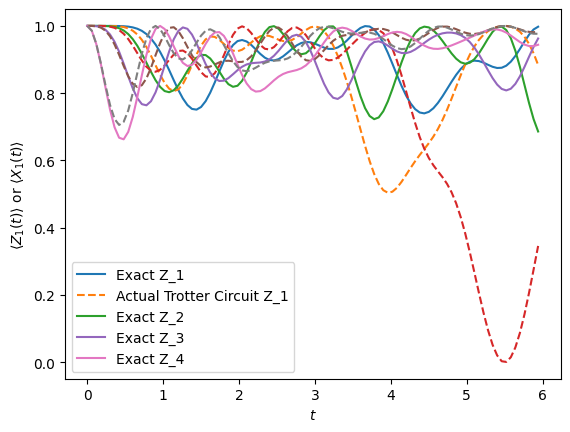

In [ ]:
# comparing PhysicalST to Classical Comparison

#testing against classicalComparison
# dt= 0.5 * 1e-2
numsteps = 100  #this doesnt really matter for Physical anymore, reps does -- for goodness of results. Can use this to reduce time it takes to run
t_tot = 6 #dt*numsteps

tlist1,zlist1 = hm.ClassicalComparison(L,Jz,1,'Z',numsteps,t_tot)
tlist2,zlist2 = PhysicalST(L,Jz,1,'Z',numsteps,t_tot,order=1,reps=reps)
tlist3,zlist3 = hm.ClassicalComparison(L,Jz,2,'Z',numsteps,t_tot)
tlist4,zlist4 = PhysicalST(L,Jz,2,'Z',numsteps,t_tot,order=1,reps=reps)
tlist5,zlist5 = hm.ClassicalComparison(L,Jz,3,'Z',numsteps,t_tot)
tlist6,zlist6 = PhysicalST(L,Jz,3,'Z',numsteps,t_tot,order=1,reps=reps)
tlist7,zlist7 = hm.ClassicalComparison(L,Jz,4,'Z',numsteps,t_tot)
tlist8,zlist8 = PhysicalST(L,Jz,4,'Z',numsteps,t_tot,order=1,reps=reps)

# tlist = [0.1 * t for t in range(500)]
plt.plot(tlist1, zlist1, label = 'Exact Z_1')
plt.plot(tlist2, zlist2, '--', label = 'Actual Trotter Circuit Z_1')
plt.plot(tlist3, zlist3, label = 'Exact Z_2')
plt.plot(tlist4, zlist4, '--')#, label = 'Actual Trotter Circuit Z_2')
plt.plot(tlist1, zlist5, label = 'Exact Z_3')
plt.plot(tlist2, zlist6, '--')#, label = 'Actual Trotter Circuit Z_3')
plt.plot(tlist3, zlist7, label = 'Exact Z_4')
plt.plot(tlist4, zlist8, '--')#, label = 'Actual Trotter Circuit Z_4')
plt.ylabel(r'$\langle Z_1(t) \rangle$ or $\langle X_1(t) \rangle$')
plt.xlabel(r'$t$')
plt.legend()
plt.show()
plt.close()

why is the trotter circuit so bad?? I guess cause only working with 7 trotter steps... And because trotterization (the approximation) relies on the time steps being small, this doesnt work very well when get to much higher

65
65
65
65


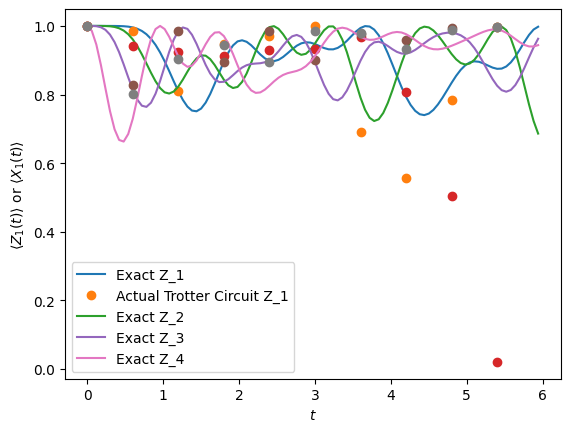

In [7]:
# comparing PhysicalST to Classical Comparison

#testing against classicalComparison
# dt= 0.5 * 1e-2
numsteps = 100  #this doesnt really matter for Physical anymore, reps does -- for goodness of results. Can use this to reduce time it takes to run
t_tot = 6 #dt*numsteps

tlist1,zlist1 = hm.ClassicalComparison(L,Jz,1,'Z',numsteps,t_tot)
tlist2,zlist2 = PhysicalST(L,Jz,1,'Z',10,t_tot,order=1,reps=reps)
tlist3,zlist3 = hm.ClassicalComparison(L,Jz,2,'Z',numsteps,t_tot)
tlist4,zlist4 = PhysicalST(L,Jz,2,'Z',10,t_tot,order=1,reps=reps)
tlist5,zlist5 = hm.ClassicalComparison(L,Jz,3,'Z',numsteps,t_tot)
tlist6,zlist6 = PhysicalST(L,Jz,3,'Z',10,t_tot,order=1,reps=reps)
tlist7,zlist7 = hm.ClassicalComparison(L,Jz,4,'Z',numsteps,t_tot)
tlist8,zlist8 = PhysicalST(L,Jz,4,'Z',10,t_tot,order=1,reps=reps)

# tlist = [0.1 * t for t in range(500)]
plt.plot(tlist1, zlist1, label = 'Exact Z_1')
plt.plot(tlist2, zlist2, 'o', label = 'Actual Trotter Circuit Z_1')
plt.plot(tlist3, zlist3, label = 'Exact Z_2')
plt.plot(tlist4, zlist4, 'o')#, label = 'Actual Trotter Circuit Z_2')
plt.plot(tlist1, zlist5, label = 'Exact Z_3')
plt.plot(tlist2, zlist6, 'o')#, label = 'Actual Trotter Circuit Z_3')
plt.plot(tlist3, zlist7, label = 'Exact Z_4')
plt.plot(tlist4, zlist8, 'o')#, label = 'Actual Trotter Circuit Z_4')
plt.ylabel(r'$\langle Z_1(t) \rangle$ or $\langle X_1(t) \rangle$')
plt.xlabel(r'$t$')
plt.legend()
plt.show()
plt.close()

Maybe we can try with just 4 qubits to see how much better/faster it performs:

47
47
47
47


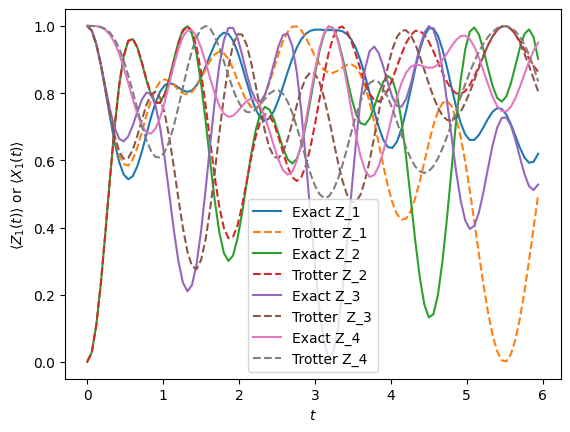

In [ ]:
# comparing PhysicalST to Classical Comparison
L=4
#testing against classicalComparison
# dt= 0.5 * 1e-2
numsteps = 100  #this doesnt really matter for Physical anymore, reps does -- for goodness of results. Can use this to reduce time it takes to run
t_tot = 6 #dt*numsteps

tlist1,zlist1 = hm.ClassicalComparison(L,Jz,1,'Z',numsteps,t_tot)
tlist2,zlist2 = PhysicalST(L,Jz,1,'Z',numsteps,t_tot,order=1,reps=reps)
tlist3,zlist3 = hm.ClassicalComparison(L,Jz,2,'Z',numsteps,t_tot)
tlist4,zlist4 = PhysicalST(L,Jz,2,'Z',numsteps,t_tot,order=1,reps=reps)
tlist5,zlist5 = hm.ClassicalComparison(L,Jz,3,'Z',numsteps,t_tot)
tlist6,zlist6 = PhysicalST(L,Jz,3,'Z',numsteps,t_tot,order=1,reps=reps)
tlist7,zlist7 = hm.ClassicalComparison(L,Jz,4,'Z',numsteps,t_tot)
tlist8,zlist8 = PhysicalST(L,Jz,4,'Z',numsteps,t_tot,order=1,reps=reps)

# tlist = [0.1 * t for t in range(500)]
plt.plot(tlist1, zlist1, 'b',label = 'Exact Z_1')
plt.plot(tlist2, zlist2, 'b--', label = 'Trotter Z_1')
plt.plot(tlist3, zlist3, 'r',label = 'Exact Z_2')
plt.plot(tlist4, zlist4, 'r--', label = 'Trotter Z_2')
plt.plot(tlist1, zlist5, 'g',label = 'Exact Z_3')
plt.plot(tlist2, zlist6, 'g--', label = 'Trotter  Z_3')
plt.plot(tlist3, zlist7, 'y',label = 'Exact Z_4')
plt.plot(tlist4, zlist8, 'y--', label = 'Trotter Z_4')
plt.ylabel(r'$\langle Z_1(t) \rangle$ or $\langle X_1(t) \rangle$')
plt.xlabel(r'$t$')
plt.legend()
plt.show()
plt.close()

this is much faster, but with only 7 trotter steps, its so bad... lets see how many trotter steps we can get for 4 qubits, keeping CNOT depth ~50

In [13]:
L=4
reps=10
PhysicalST(L,Jz,1,'Z',1,t_tot,order=1,reps=reps)

65


(array([0.]), array([1.]))

That's promising, lets plot that:

65
65
65
65


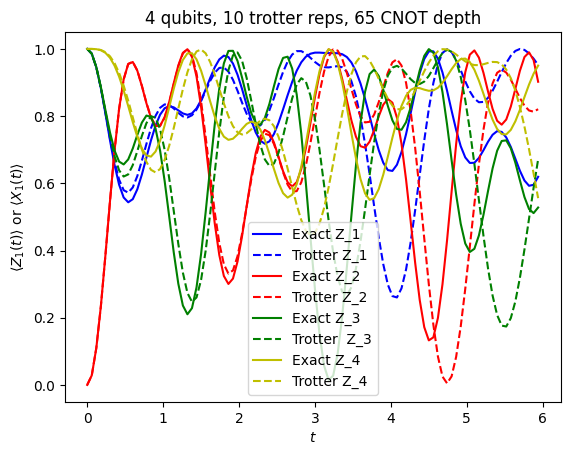

In [19]:
# comparing PhysicalST to Classical Comparison
L=4
#testing against classicalComparison
# dt= 0.5 * 1e-2
numsteps = 100  #this doesnt really matter for Physical anymore, reps does -- for goodness of results. Can use this to reduce time it takes to run
t_tot = 6 #dt*numsteps

tlist1,zlist1 = hm.ClassicalComparison(L,Jz,1,'Z',numsteps,t_tot)
tlist2,zlist2 = PhysicalST(L,Jz,1,'Z',numsteps,t_tot,order=1,reps=reps)
tlist3,zlist3 = hm.ClassicalComparison(L,Jz,2,'Z',numsteps,t_tot)
tlist4,zlist4 = PhysicalST(L,Jz,2,'Z',numsteps,t_tot,order=1,reps=reps)
tlist5,zlist5 = hm.ClassicalComparison(L,Jz,3,'Z',numsteps,t_tot)
tlist6,zlist6 = PhysicalST(L,Jz,3,'Z',numsteps,t_tot,order=1,reps=reps)
tlist7,zlist7 = hm.ClassicalComparison(L,Jz,4,'Z',numsteps,t_tot)
tlist8,zlist8 = PhysicalST(L,Jz,4,'Z',numsteps,t_tot,order=1,reps=reps)

# tlist = [0.1 * t for t in range(500)]
plt.plot(tlist1, zlist1, 'b', label = 'Exact Z_1')
plt.plot(tlist2, zlist2, 'b--', label = 'Trotter Z_1')
plt.plot(tlist3, zlist3, 'r',label = 'Exact Z_2')
plt.plot(tlist4, zlist4, 'r--', label = 'Trotter Z_2')
plt.plot(tlist1, zlist5, 'g', label = 'Exact Z_3')
plt.plot(tlist2, zlist6, 'g--', label = 'Trotter  Z_3')
plt.plot(tlist3, zlist7, 'y', label = 'Exact Z_4')
plt.plot(tlist4, zlist8, 'y--', label = 'Trotter Z_4')
plt.ylabel(r'$\langle Z_1(t) \rangle$ or $\langle X_1(t) \rangle$')
plt.xlabel(r'$t$')
plt.title('4 qubits, 10 trotter reps, 65 CNOT depth')
plt.legend()
plt.show()
plt.close()

So maybe we should go with just 4 qubits, so we can get more accurate results. Cause these plots are even without noise, which will be quite high with a circuit depth of 65. We can run a few tries on the quantum chip to see


This plot is okayyyy for Z_2, but not really for others. Why so much difference? Is it because of just where the timesteps end up, randomly? My assumption would be that tighter turnarounds, etc would cause more error, but the Z_2 seems to have the tightest turnaround of all. Maybe smaller osciallations are harder to capture?

to do: build a function (or for loop) that can take a list for timestep values, so that we can get a few data points at different intervals (closer together for earlier times). and then able to run every trotter/measurement as a separate job. 

experiment with how much computing time these things take...